# Setup
In this section, we will install and set our paths to our dataset. We first install the libraries. Each library is mentioned with its specified reason:
- `os` - to 
- `matplotlib` - to display the images before processing, after processing

In [16]:
# 1. Standard Library Imports
import os
import pickle
import warnings
from pathlib import Path
from collections import Counter
from itertools import product
from copy import deepcopy

# 2. Third-Party Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim

# 3. Machine Learning & Scikit-Learn Imports
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 4. Deep Learning & PyTorch Imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics import Accuracy

# Configure environment
warnings.filterwarnings('ignore')

After this, we will set our paths accordingly to point to the train, valid and test folders.

In [2]:
dataset_path = Path('C:\\Users\Gracie\Downloads\Machine Learning\dataset')
training_data_path = dataset_path / 'train'
validation_data_path = dataset_path / 'valid'
testing_data_path = dataset_path / 'test'

# Verify the paths
print(f"Dataset path exists: {dataset_path.exists()}")
print(f"Training path exists: {training_data_path.exists()}")
print(f"Validation path exists: {validation_data_path.exists()}")
print(f"Testing path exists: {testing_data_path.exists()}")

Dataset path exists: True
Training path exists: True
Validation path exists: True
Testing path exists: True


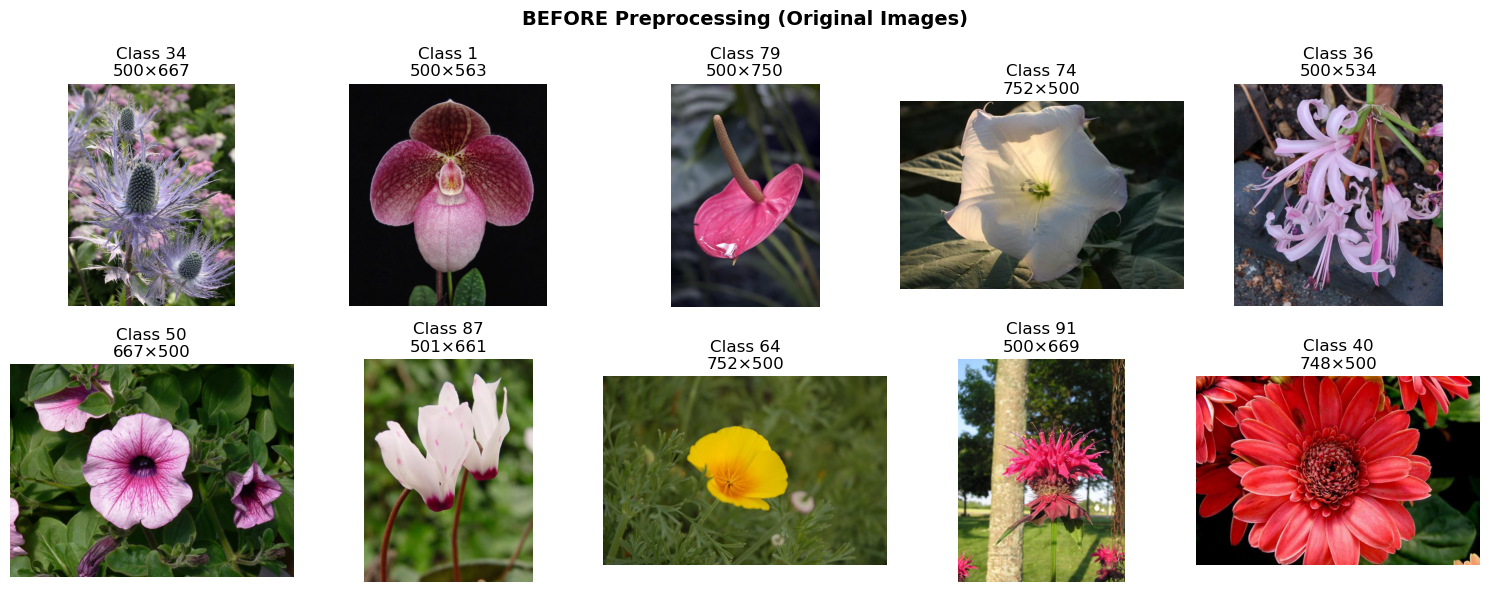

Original image properties:
  - Various sizes (not standardized)
  - RGB format (3 channels)
  - Pixel values: 0-255


In [3]:
# ============================================================================
# BEFORE Preprocessing (Original Images)
# ============================================================================

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# STEP 1: Collect all image paths FIRST
all_image_paths = []
all_labels = []

for label, folder in enumerate(sorted(training_data_path.iterdir(), key=lambda x: int(x.name))):
    if folder.is_dir():
        for img_path in folder.glob('*.jpg'):
            all_image_paths.append(img_path)
            all_labels.append(label)

# STEP 2: Generate random indices with SAME seed as comparison
np.random.seed(10)
random_indices = np.random.choice(len(all_image_paths), 10, replace=False)

# STEP 3: Display
for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    img = Image.open(all_image_paths[img_idx])
    ax.imshow(img)
    ax.set_title(f"Class {all_labels[img_idx]}\n{img.size[0]}×{img.size[1]}")
    ax.axis('off')

plt.suptitle("BEFORE Preprocessing (Original Images)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Original image properties:")
print("  - Various sizes (not standardized)")
print("  - RGB format (3 channels)")
print("  - Pixel values: 0-255")

# Verification Step
After installing and setting up the folder paths, we will need to inspect and understand our dataset. From there, we will need to process our data to see if there's any issues with it such as defected or corrupted images.

## Count number of images
In our given dataset, it is split across 3 different folders. We have our training set, validation set and our test set. Our training set and validation set contains several folders. These folders are our classes, representing our type of plants.

In [6]:
def count_images_per_class(data_dir):
    """Count the number of images in each class folder."""
    class_counts = {}
    for class_folder in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_folder] = num_images
    return class_counts

def count_images_flat(data_dir):
    return len([
        f for f in os.listdir(data_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

In [7]:
# Count images in each split
# For the test set, we will use the count from check_corrupted_images if it doesn't have class subfolders.
# The test_counts will be 0 if there are no subdirectories.
train_counts = count_images_per_class(training_data_path)
valid_counts = count_images_per_class(validation_data_path)
test_counts = count_images_per_class(testing_data_path)
test_image_count = count_images_flat(testing_data_path)

print(f"Training set: {sum(train_counts.values())} images across {len(train_counts)} classes")
print(f"Validation set: {sum(valid_counts.values())} images across {len(valid_counts)} classes")
print(f"Test set: {test_image_count} images (no class subfolders)")


Training set: 6552 images across 102 classes
Validation set: 818 images across 102 classes
Test set: 819 images (no class subfolders)


## Check for corrupted images
It's possible for our dataset to include corrupt or defected images. We need to verify if this is or isn't the case.

In [8]:
def check_corrupted_images(folder_path):
    """
    Scan all images in a folder and check if they can be opened.
    Returns lists of valid and corrupted image paths.
    """
    valid_images = []
    corrupted_images = []

    # Walk through all subfolders (class folders)
    for root, directories, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    # Try to open and verify the image
                    with Image.open(img_path) as img:
                        img.verify()  # This checks if file is corrupted
                    valid_images.append(img_path)
                except Exception as e:
                    corrupted_images.append((img_path, str(e)))

    return valid_images, corrupted_images

In [9]:
# Run on each split
print("Checking TRAIN folder...")
train_valid, train_corrupted = check_corrupted_images(training_data_path)
print(f"  Valid: {len(train_valid)}, Corrupted: {len(train_corrupted)}")

print("Checking VALID folder...")
valid_valid, valid_corrupted = check_corrupted_images(validation_data_path)
print(f"  Valid: {len(valid_valid)}, Corrupted: {len(valid_corrupted)}")

print("Checking TEST folder...")
test_valid, test_corrupted = check_corrupted_images(testing_data_path)
print(f"  Valid: {len(test_valid)}, Corrupted: {len(test_corrupted)}")

# Show corrupted files if any
if train_corrupted:
    print("\n⚠️ Corrupted files in TRAIN:")
    for path, error in train_corrupted:
        print(f"  {path}: {error}")

Checking TRAIN folder...
  Valid: 6552, Corrupted: 0
Checking VALID folder...
  Valid: 818, Corrupted: 0
Checking TEST folder...
  Valid: 819, Corrupted: 0


In [10]:
def check_flipped_images(folder_path):
    """
    Scans images for EXIF orientation tags which indicate the image 
    might be rotated or flipped.
    """
    flipped_count = 0
    total_images = 0
    affected_files = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        # EXIF tag 274 is 'Orientation'
                        exif = img._getexif()
                        if exif and 274 in exif:
                            orientation = exif[274]
                            # Orientations 2-8 imply some form of flipping or rotation
                            if orientation > 1:
                                flipped_count += 1
                                affected_files.append(img_path)
                except (AttributeError, KeyError, IndexError):
                    # No EXIF data found, assuming image is standard
                    pass
                except Exception as e:
                    print(f"Error checking {img_path}: {e}")

    print(f"Folder: {folder_path}")
    print(f"  - Total images scanned: {total_images}")
    print(f"  - Flipped/Rotated images detected: {flipped_count}")
    return affected_files

# Run the check on all paths
print("Checking for orientation issues...")
train_flipped = check_flipped_images(training_data_path)
valid_flipped = check_flipped_images(validation_data_path)
test_flipped = check_flipped_images(testing_data_path)

Checking for orientation issues...
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\train
  - Total images scanned: 6552
  - Flipped/Rotated images detected: 0
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\valid
  - Total images scanned: 818
  - Flipped/Rotated images detected: 0
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\test
  - Total images scanned: 819
  - Flipped/Rotated images detected: 0


## Get image statistics

In [11]:
def get_image_stats(folder_path):
    """
    Collect dimension and file size statistics for all images.
    """
    dimensions = []
    file_sizes = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)  # (width, height)
                    file_sizes.append(os.path.getsize(img_path))
                except:
                    pass

    return dimensions, file_sizes

In [12]:
# Get stats for training set
dimensions, file_sizes = get_image_stats(training_data_path)

widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print("=" * 50)
print("IMAGE DIMENSION STATISTICS (Training Set)")
print("=" * 50)
print(f"Total images: {len(dimensions)}")
print(f"\nWidth:")
print(f"  Min: {min(widths)} px")
print(f"  Max: {max(widths)} px")
print(f"  Mean: {np.mean(widths):.1f} px")
print(f"\nHeight:")
print(f"  Min: {min(heights)} px")
print(f"  Max: {max(heights)} px")
print(f"  Mean: {np.mean(heights):.1f} px")
print(f"\nFile size:")
print(f"  Min: {min(file_sizes)/1024:.1f} KB")
print(f"  Max: {max(file_sizes)/1024:.1f} KB")
print(f"  Mean: {np.mean(file_sizes)/1024:.1f} KB")

IMAGE DIMENSION STATISTICS (Training Set)
Total images: 6552

Width:
  Min: 500 px
  Max: 1024 px
  Mean: 630.4 px

Height:
  Min: 500 px
  Max: 1168 px
  Mean: 534.3 px

File size:
  Min: 11.7 KB
  Max: 121.7 KB
  Mean: 41.3 KB


## Identify the distribution
We need to understand if our dataset is enough for each class. We expect the classes to be within a close range of numbers

In [13]:
def get_class_distribution(folder_path):
    """
    Count how many images are in each class folder.
    """
    class_counts = {}

    # Each subfolder is a class (named 1, 2, 3, ... 102)
    for class_folder in sorted(Path(folder_path).iterdir()):
        if class_folder.is_dir():
            class_name = class_folder.name
            # Count images in this class
            num_images = len(list(class_folder.glob("*.jpg"))) + \
                        len(list(class_folder.glob("*.png")))
            class_counts[class_name] = num_images
            
    return class_counts

In [14]:
# Get distribution
train_distribution = get_class_distribution(training_data_path)

# Convert to sorted list for analysis
class_names = sorted(train_distribution.keys(), key=lambda x: int(x))
counts = [train_distribution[c] for c in class_names]

print("=" * 50)
print("CLASS DISTRIBUTION (Training Set)")
print("=" * 50)
print(f"Number of classes: {len(train_distribution)}")
print(f"Total images: {sum(counts)}")
print(f"\nImages per class:")
print(f"  Min: {min(counts)} (Class {class_names[counts.index(min(counts))]})")
print(f"  Max: {max(counts)} (Class {class_names[counts.index(max(counts))]})")
print(f"  Mean: {np.mean(counts):.1f}")
print(f"  Std Dev: {np.std(counts):.1f}")

# Find underrepresented classes (less than mean - 1 std)
threshold = np.mean(counts) - np.std(counts)
underrepresented = [(c, train_distribution[c]) for c in class_names
                    if train_distribution[c] < threshold]

if underrepresented:
    print(f"\n⚠️ Underrepresented classes (< {threshold:.0f} images):")
    for cls, count in sorted(underrepresented, key=lambda x: x[1])[:10]:
        print(f"  Class {cls}: {count} images")

CLASS DISTRIBUTION (Training Set)
Number of classes: 102
Total images: 6552

Images per class:
  Min: 27 (Class 1)
  Max: 206 (Class 51)
  Mean: 64.2
  Std Dev: 35.2

⚠️ Underrepresented classes (< 29 images):
  Class 1: 27 images
  Class 34: 28 images


## Standardise image colour coding and normalise pixel values

In [15]:
from collections import Counter

def check_for_grayscale_and_color_modes(folder_path, dataset_name="Dataset"):
    """
    Checks for RGB, Grayscale ('L'), and other color modes.
    Reports explicitly if grayscale images are found.
    """
    mode_counts = Counter()
    total_images = 0
    grayscale_paths = []
    
    # Mapping codes to human-readable names
    mode_names = {
        'RGB': 'Standard Color (RGB)',
        'L': 'Grayscale (1-channel)',
        'RGBA': 'Color with Transparency (RGBA)',
        'P': 'Palette-based Color',
        '1': 'Black & White (Binary)',
        'CMYK': 'Print Color (CMYK)'
    }

    print(f"Scanning {dataset_name} for color consistency...")
    
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        m = img.mode
                        mode_counts[m] += 1
                        # Capture paths for manual review if they are grayscale
                        if m == 'L' or m == '1':
                            grayscale_paths.append(img_path)
                except Exception as e:
                    print(f"Error: {img_path} - {e}")

    # Final Report
    print(f"\n--- {dataset_name} Color Mode Report ---")
    print(f"Total Images Scanned: {total_images}")
    
    for mode, count in mode_counts.items():
        name = mode_names.get(mode, f"Unknown Mode ({mode})")
        percentage = (count / total_images) * 100
        print(f"  * {name}: {count} images ({percentage:.1f}%)")

    if len(grayscale_paths) > 0:
        print(f"\n⚠️ ACTION REQUIRED: {len(grayscale_paths)} grayscale images detected.")
        print("These must be converted to RGB to match the 3-channel input of your model.")
    else:
        print("\n✅ Success: No grayscale images detected. All images have color channels.")

# Run the check
check_for_grayscale_and_color_modes(training_data_path, "TRAIN")
check_for_grayscale_and_color_modes(validation_data_path, "VALID")
check_for_grayscale_and_color_modes(testing_data_path, "TEST")

Scanning TRAIN for color consistency...

--- TRAIN Color Mode Report ---
Total Images Scanned: 6552
  * Standard Color (RGB): 6552 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning VALID for color consistency...

--- VALID Color Mode Report ---
Total Images Scanned: 818
  * Standard Color (RGB): 818 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning TEST for color consistency...

--- TEST Color Mode Report ---
Total Images Scanned: 819
  * Standard Color (RGB): 819 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.


# Data Preprocessing: Block-Based SVD

## Overview
We apply **block-based SVD** to compress images while preserving local details:
1. Resize each image to 128×128
2. Split into 16 blocks (4×4 grid of 32×32 blocks)
3. Apply SVD with k components to each block independently
4. Store the compressed SVD components (U_k, Σ_k, V_T_k) for each block

**Why block-based?**
- Preserves local details (flower petals, edges, textures)
- Each block captures its own important features
- Result: Sharper images compared to whole-image SVD

## Configuration

In [33]:
# ============================================================================
# Block-Based SVD Parameters
# ============================================================================

# Primary parameters
IMAGE_SIZE = (128, 128)      # Standardized image size
BLOCK_SIZE = 32              # Size of each block for block-based SVD
n_samples = 50              # Number of sample images to analyze
target_ssim = 0.90          # Target image quality

def find_optimal_k_for_blocks(data_path, image_size, block_size, 
                               target_ssim=0.80, n_samples=50):
    """
    Find optimal k for block-based SVD by testing on sample blocks.
    
    Process:
    1. Sample images from dataset
    2. For each image, test random blocks
    3. For each block, find minimum k where SSIM ≥ target
    4. Return median k across all tested blocks
    """
    print("\n" + "="*70)
    print("DETERMINING OPTIMAL k FOR BLOCK-BASED SVD")
    print("="*70)
    print(f"Testing on: {block_size}×{block_size} BLOCKS")
    print(f"Target SSIM per block: {target_ssim:.0%}")
    print(f"Analyzing {n_samples} sample images...\n")
    
    k_values = []
    
    folders = sorted([f for f in Path(data_path).iterdir() if f.is_dir()],
                    key=lambda x: int(x.name))[:10]
    
    sample_count = 0
    for folder in folders:
        for img_path in list(folder.glob('*.jpg'))[:5]:
            if sample_count >= n_samples:
                break
            
            # Load and resize
            img = Image.open(img_path).convert('RGB')
            img = img.resize(image_size, Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=np.float64)
            
            H, W = img_array.shape[:2]
            num_blocks_h = H // block_size
            num_blocks_w = W // block_size
            
            # Test k on random blocks
            for channel in range(3):  # RGB channels
                channel_data = img_array[:, :, channel]
                
                # Sample 3 random blocks per channel
                for _ in range(3):
                    i = np.random.randint(0, num_blocks_h)
                    j = np.random.randint(0, num_blocks_w)
                    
                    # Extract block
                    row_start = i * block_size
                    row_end = (i + 1) * block_size
                    col_start = j * block_size
                    col_end = (j + 1) * block_size
                    block = channel_data[row_start:row_end, col_start:col_end]
                    
                    # Apply SVD
                    U, sigma, V_T = np.linalg.svd(block, full_matrices=False)
                    
                    # Find minimum k that achieves target SSIM
                    for k_test in range(5, min(block_size + 1, len(sigma) + 1), 5):
                        U_k = U[:, :k_test]
                        sigma_k = sigma[:k_test]
                        V_T_k = V_T[:k_test, :]
                        reconstructed = U_k @ np.diag(sigma_k) @ V_T_k
                        
                        ssim_score = ssim(block, reconstructed, data_range=255.0)
                        
                        if ssim_score >= target_ssim:
                            k_values.append(k_test)
                            break
                    else:
                        # Didn't reach target SSIM
                        k_values.append(min(block_size, len(sigma)))
            
            sample_count += 1
            if (sample_count % 10) == 0:
                print(f"  Processed {sample_count}/{n_samples} images...")
    
    # Calculate statistics
    recommended_k = int(np.median(k_values))
    
    print("\n" + "="*70)
    print("RESULTS")
    print("="*70)
    print(f"Analyzed: {len(k_values)} blocks from {sample_count} images")
    print(f"  ({sample_count} images × 3 channels × 3 blocks = {len(k_values)} blocks)")
    
    print(f"\nk value distribution:")
    print(f"  k range: {min(k_values)} to {max(k_values)}")
    print(f"  k median: {recommended_k}")
    print(f"  k mean: {np.mean(k_values):.1f}")
    print(f"  k std dev: {np.std(k_values):.2f}")
    
    print(f"\nAt k={recommended_k} per block:")
    print(f"  SSIM achieved: ≥{target_ssim:.0%} ✓")
    
    # Calculate total features
    num_blocks_total = (image_size[0]//block_size) * (image_size[1]//block_size)
    features_per_block = block_size*recommended_k + recommended_k + recommended_k*block_size
    total_features = features_per_block * num_blocks_total * 3
    original_pixels = image_size[0] * image_size[1] * 3
    compression = original_pixels / total_features
    
    print(f"\nWith k={recommended_k}:")
    print(f"  Features per block: {features_per_block:,}")
    print(f"  Total blocks: {num_blocks_total}")
    print(f"  Total features: {total_features:,}")
    print(f"  Original pixels: {original_pixels:,}")
    print(f"  Compression ratio: {compression:.2f}×")
    
    print("\n" + "="*70)
    print(f"✓ RECOMMENDED k = {recommended_k} (for {block_size}×{block_size} blocks)")
    print("="*70)
    
    return recommended_k


# Find optimal k
k = find_optimal_k_for_blocks(
    training_data_path, 
    IMAGE_SIZE, 
    BLOCK_SIZE,
    target_ssim=target_ssim,
    n_samples=n_samples
)


DETERMINING OPTIMAL k FOR BLOCK-BASED SVD
Testing on: 32×32 BLOCKS
Target SSIM per block: 90%
Analyzing 50 sample images...

  Processed 10/50 images...
  Processed 20/50 images...
  Processed 30/50 images...
  Processed 40/50 images...
  Processed 50/50 images...

RESULTS
Analyzed: 450 blocks from 50 images
  (50 images × 3 channels × 3 blocks = 450 blocks)

k value distribution:
  k range: 5 to 15
  k median: 10
  k mean: 8.6
  k std dev: 2.71

At k=10 per block:
  SSIM achieved: ≥90% ✓

With k=10:
  Features per block: 650
  Total blocks: 16
  Total features: 31,200
  Original pixels: 49,152
  Compression ratio: 1.58×

✓ RECOMMENDED k = 10 (for 32×32 blocks)


## Block-Based SVD Functions

These functions handle the compression and reconstruction of images using block-based SVD.

In [7]:
def svd_compress_image_blocks(image_path, k, image_size, block_size, 
                               return_metadata=False):
    """
    Compress image using block-based SVD.
    
    Process:
    1. Load and resize image to image_size
    2. Split into blocks of size block_size × block_size
    3. Apply SVD to each block, keeping k components
    4. Store U_k, Σ_k, V_T_k for each block
    
    Args:
        image_path: Path to image file
        k: Number of SVD components per block
        image_size: Target size (H, W)
        block_size: Size of each block
        return_metadata: If True, also return reconstruction and quality metrics
    
    Returns:
        features: 1D array of concatenated SVD components from all blocks
        metadata: (optional) Dict with reconstruction and quality info
    """
    # Load and resize image
    img = Image.open(image_path).convert('RGB')
    img = img.resize(image_size, Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float64)
    
    H, W = img_array.shape[:2]
    num_blocks_h = H // block_size
    num_blocks_w = W // block_size
    
    all_features = []
    reconstructed_channels = [] if return_metadata else None
    
    # Process each RGB channel
    for channel_idx in range(3):
        channel_data = img_array[:, :, channel_idx]
        channel_features = []
        reconstructed_blocks = [] if return_metadata else None
        
        # Process each block
        for i in range(num_blocks_h):
            for j in range(num_blocks_w):
                # Extract block
                row_start, row_end = i * block_size, (i + 1) * block_size
                col_start, col_end = j * block_size, (j + 1) * block_size
                block = channel_data[row_start:row_end, col_start:col_end]
                
                # Apply SVD to block
                U, sigma, V_T = np.linalg.svd(block, full_matrices=False)
                U_k = U[:, :k]
                sigma_k = sigma[:k]
                V_T_k = V_T[:k, :]
                
                # Store SVD components
                block_features = np.concatenate([
                    U_k.flatten(),  # block_size × k values
                    sigma_k,        # k values
                    V_T_k.flatten() # k × block_size values
                ])
                channel_features.append(block_features)
                
                # Reconstruct if needed
                if return_metadata:
                    reconstructed_block = U_k @ np.diag(sigma_k) @ V_T_k
                    reconstructed_blocks.append((i, j, reconstructed_block))
        
        # Concatenate all blocks for this channel
        all_features.append(np.concatenate(channel_features))
        
        # Reconstruct full channel if needed
        if return_metadata:
            reconstructed_channel = np.zeros((H, W))
            for i, j, block in reconstructed_blocks:
                row_start, row_end = i * block_size, (i + 1) * block_size
                col_start, col_end = j * block_size, (j + 1) * block_size
                reconstructed_channel[row_start:row_end, col_start:col_end] = block
            reconstructed_channels.append(reconstructed_channel)
    
    # Concatenate features from all channels
    features = np.concatenate(all_features)
    
    if return_metadata:
        reconstructed_img = np.stack(reconstructed_channels, axis=-1)
        reconstructed_img = np.clip(reconstructed_img, 0, 255)
        ssim_score = ssim(img_array, reconstructed_img, 
                         channel_axis=2, data_range=255.0)
        
        metadata = {
            'k': k,
            'block_size': block_size,
            'ssim': ssim_score,
            'reconstructed': reconstructed_img
        }
        return features, metadata
    else:
        return features


def reconstruct_from_blocks(features, k, image_size, block_size):
    """
    Reconstruct image from block-based SVD components.
    
    Args:
        features: 1D array of SVD components
        k: Number of components per block
        image_size: Target size (H, W)
        block_size: Block size used during compression
    
    Returns:
        reconstructed_img: Reconstructed image array (H, W, 3)
    """
    H, W = image_size
    num_blocks_h = H // block_size
    num_blocks_w = W // block_size
    features_per_block = block_size*k + k + k*block_size
    features_per_channel = features_per_block * num_blocks_h * num_blocks_w
    
    reconstructed_channels = []
    
    for channel_idx in range(3):
        # Get features for this channel
        start_idx = channel_idx * features_per_channel
        channel_features = features[start_idx:start_idx + features_per_channel]
        reconstructed_channel = np.zeros((H, W))
        
        # Reconstruct each block
        block_idx = 0
        for i in range(num_blocks_h):
            for j in range(num_blocks_w):
                # Extract block features
                block_start = block_idx * features_per_block
                block_features = channel_features[block_start:block_start + features_per_block]
                
                # Parse SVD components
                idx = 0
                U_k = block_features[idx:idx + block_size*k].reshape(block_size, k)
                idx += block_size*k
                sigma_k = block_features[idx:idx + k]
                idx += k
                V_T_k = block_features[idx:idx + k*block_size].reshape(k, block_size)
                
                # Reconstruct block
                reconstructed_block = U_k @ np.diag(sigma_k) @ V_T_k
                
                # Place in channel
                row_start, row_end = i * block_size, (i + 1) * block_size
                col_start, col_end = j * block_size, (j + 1) * block_size
                reconstructed_channel[row_start:row_end, col_start:col_end] = reconstructed_block
                
                block_idx += 1
        
        reconstructed_channels.append(reconstructed_channel)
    
    # Stack channels
    reconstructed_img = np.stack(reconstructed_channels, axis=-1)
    reconstructed_img = np.clip(reconstructed_img, 0, 255)
    
    return reconstructed_img


print("Block-based SVD functions defined.")

Block-based SVD functions defined.


## Verify Block-Based SVD

Test the compression on a single image to verify it works correctly.

In [36]:
# ============================================================================
# VERIFY BLOCK-BASED SVD
# ============================================================================

print("="*70)
print("TESTING BLOCK-BASED SVD ON SAMPLE IMAGE")
print("="*70)

# Get a test image
test_folders = sorted([f for f in training_data_path.iterdir() if f.is_dir()],
                     key=lambda x: int(x.name))
test_img_path = list(test_folders[0].glob('*.jpg'))[0]

print(f"\nTest image: {test_img_path.name}")
print(f"Configuration:")
print(f"  IMAGE_SIZE: {IMAGE_SIZE}")
print(f"  BLOCK_SIZE: {BLOCK_SIZE}")
print(f"  k: {k}")

# Compress
features, metadata = svd_compress_image_blocks(
    test_img_path, k, IMAGE_SIZE, BLOCK_SIZE, return_metadata=True
)

# Calculate statistics
num_blocks = (IMAGE_SIZE[0]//BLOCK_SIZE) * (IMAGE_SIZE[1]//BLOCK_SIZE)
features_per_block = BLOCK_SIZE*k + k + k*BLOCK_SIZE
original_pixels = IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3

print(f"\n✓ Compression successful!")
print(f"  Blocks: {num_blocks} ({IMAGE_SIZE[0]//BLOCK_SIZE}×{IMAGE_SIZE[1]//BLOCK_SIZE})")
print(f"  Features per block: {features_per_block:,}")
print(f"  Total features: {len(features):,}")
print(f"  Original pixels: {original_pixels:,}")
print(f"  Compression ratio: {original_pixels / len(features):.2f}×")
print(f"  SSIM: {metadata['ssim']:.4f}")

if metadata['ssim'] >= 0.90:
    print(f"  ✓ Quality check passed (SSIM ≥ 0.90)")
else:
    print(f"  ⚠️  Quality below target (SSIM < 0.90)")

print("="*70)

TESTING BLOCK-BASED SVD ON SAMPLE IMAGE

Test image: image_06734.jpg
Configuration:
  IMAGE_SIZE: (128, 128)
  BLOCK_SIZE: 32
  k: 10

✓ Compression successful!
  Blocks: 16 (4×4)
  Features per block: 650
  Total features: 31,200
  Original pixels: 49,152
  Compression ratio: 1.58×
  SSIM: 0.9556
  ✓ Quality check passed (SSIM ≥ 0.90)


## Process All Datasets

Apply block-based SVD to training, validation, and test sets.

**Note:** This uses standardized variable naming: `X_train`, `X_valid`, `X_test`

In [37]:
def process_folder_with_classes(data_path, k, image_size, block_size):
    """Process dataset with class labels using block-based SVD"""
    X, y = [], []
    class_names = []
    ssim_scores = []
    
    folders = sorted([f for f in data_path.iterdir() if f.is_dir()],
                     key=lambda x: int(x.name))
    
    print(f"Processing {len(folders)} classes...")
    for label, folder in enumerate(folders):
        class_names.append(folder.name)
        count = 0
        
        for img_path in folder.glob('*.jpg'):
            try:
                features, meta = svd_compress_image_blocks(
                    img_path, k, image_size, block_size, return_metadata=True
                )
                X.append(features)
                y.append(label)
                ssim_scores.append(meta['ssim'])
                count += 1
            except Exception as e:
                print(f"  ⚠️  Skipped {img_path.name}: {e}")
        
        if (label + 1) % 20 == 0:
            print(f"  Processed {label + 1}/{len(folders)} classes...")
    
    avg_ssim = np.mean(ssim_scores)
    print(f"\n✓ Processing complete:")
    print(f"  Total images: {len(X):,}")
    print(f"  Average SSIM: {avg_ssim:.4f}")
    
    return np.array(X), np.array(y), class_names


def process_folder_flat(data_path, k, image_size, block_size):
    """Process test dataset (no class structure) using block-based SVD"""
    X, filenames = [], []
    
    print("Processing test images...")
    for img_path in sorted(data_path.glob('*.jpg')):
        try:
            features = svd_compress_image_blocks(
                img_path, k, image_size, block_size, return_metadata=False
            )
            X.append(features)
            filenames.append(img_path.name)
        except Exception as e:
            print(f"  ⚠️  Skipped {img_path.name}: {e}")
    
    print(f"✓ Processed {len(X):,} test images")
    return np.array(X), filenames

In [38]:
# Process with block-based method
print("\n📁 Training data...")
X_train, y_train, class_names = process_folder_with_classes(
    training_data_path, k, IMAGE_SIZE, BLOCK_SIZE
)

print("\n📁 Validation data...")
X_valid, y_valid, _ = process_folder_with_classes(
    validation_data_path, k, IMAGE_SIZE, BLOCK_SIZE
)

print("\n📁 Test data...")
X_test, test_filenames = process_folder_flat(
    testing_data_path, k, IMAGE_SIZE, BLOCK_SIZE
)

print(f"\n✓ Block-Based SVD Complete:")
print(f"  X_train: {X_train.shape}")
print(f"  X_valid: {X_valid.shape}")
print(f"  X_test:  {X_test.shape}")



📁 Training data...
Processing 102 classes...
  Processed 20/102 classes...
  Processed 40/102 classes...
  Processed 60/102 classes...
  Processed 80/102 classes...
  Processed 100/102 classes...

✓ Processing complete:
  Total images: 6,552
  Average SSIM: 0.9600

📁 Validation data...
Processing 102 classes...
  Processed 20/102 classes...
  Processed 40/102 classes...
  Processed 60/102 classes...
  Processed 80/102 classes...
  Processed 100/102 classes...

✓ Processing complete:
  Total images: 818
  Average SSIM: 0.9602

📁 Test data...
Processing test images...
✓ Processed 819 test images

✓ Block-Based SVD Complete:
  X_train: (6552, 31200)
  X_valid: (818, 31200)
  X_test:  (819, 31200)


## Saving Processed Features
This section will store the feature vectors (1D arrays) after extracting the U_k, Σ_k, V_T_k components and flattening them into a single vector.

**Explanation:** <br>
Feature-Based models like Logistic Regression and ANN expects feature vectors while CNN needs images as they rely on spatial structure (edges, textures) to learn patterns.

In [39]:
print("\n" + "="*80)
print("SAVING PREPROCESSED DATA")
print("="*80)

# Define save location
save_dir = Path(dataset_path)  # or wherever you want
save_dir.mkdir(exist_ok=True)  # Create directory if it doesn't exist
save_path = save_dir / 'preprocessed_flower_data.pkl'

# Prepare data dictionary
data_to_save = {
    # Preprocessed features
    'X_train': X_train,
    'y_train': y_train,
    'X_valid': X_valid,
    'y_valid': y_valid,
    'X_test': X_test,
    'test_filenames': test_filenames,
    
    # Configuration
    'IMAGE_SIZE': IMAGE_SIZE,
    'BLOCK_SIZE': BLOCK_SIZE,
    'k': k,
    'class_names': class_names,
    
    # Metadata
    'preprocessing_method': 'block_based_svd',
    'features_per_image': X_train.shape[1],
    'num_classes': len(class_names),
    'num_blocks': (IMAGE_SIZE[0]//BLOCK_SIZE) * (IMAGE_SIZE[1]//BLOCK_SIZE)
}

print(f"\n📦 Data to save:")
print(f"  X_train: {X_train.shape}")
print(f"  X_valid: {X_valid.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Configuration: IMAGE_SIZE={IMAGE_SIZE}, BLOCK_SIZE={BLOCK_SIZE}, k={k}")

print(f"\n💾 Saving to: {save_path}")

with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

file_size = save_path.stat().st_size / (1024**2)

print(f"✅ SAVED SUCCESSFULLY!")
print(f"   File: {save_path.name}")
print(f"   Size: {file_size:.1f} MB")


SAVING PREPROCESSED DATA

📦 Data to save:
  X_train: (6552, 31200)
  X_valid: (818, 31200)
  X_test:  (819, 31200)
  Configuration: IMAGE_SIZE=(128, 128), BLOCK_SIZE=32, k=10

💾 Saving to: C:\Users\Gracie\Downloads\Machine Learning\dataset\preprocessed_flower_data.pkl
✅ SAVED SUCCESSFULLY!
   File: preprocessed_flower_data.pkl
   Size: 1949.3 MB


## Load Preprocessed Features

In [10]:
print("="*70)
print("LOADING PREPROCESSED FEATURES")
print("="*70)

# Load
load_path = Path(dataset_path , 'preprocessed_flower_data.pkl')

if not load_path.exists():
    print(f"❌ ERROR: File not found at {load_path}")
    print("   Please run the preprocessing and save cells first.")
else:
    print(f"📂 Loading from: {load_path}")
    
    with open(load_path, 'rb') as f:
        data = pickle.load(f)
    
    # Extract all variables
    X_train = data['X_train']
    y_train = data['y_train']
    X_valid = data['X_valid']
    y_valid = data['y_valid']
    X_test = data['X_test']
    test_filenames = data['test_filenames']
    IMAGE_SIZE = data['IMAGE_SIZE']
    BLOCK_SIZE = data['BLOCK_SIZE']
    k = data['k']
    class_names = data['class_names']
    
    print(f"✅ LOADED SUCCESSFULLY!\n")

LOADING PREPROCESSED FEATURES
📂 Loading from: C:\Users\Gracie\Downloads\Machine Learning\dataset\preprocessed_flower_data.pkl
✅ LOADED SUCCESSFULLY!



Print (processed) dataset information.

In [5]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
    
print(f"\n📊 Data Shapes:")
print(f"   Training:   X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"   Validation: X_valid = {X_valid.shape}, y_valid = {y_valid.shape}")
print(f"   Test:       X_test = {X_test.shape}")
    
print(f"\n⚙️  Configuration:")
print(f"   Method: {data['preprocessing_method']}")
print(f"   Image size: {IMAGE_SIZE}")
print(f"   Block size: {BLOCK_SIZE}×{BLOCK_SIZE}")
print(f"   k (per block): {k}")
print(f"   Blocks per image: {data['num_blocks']}")
print(f"   Features per image: {data['features_per_image']:,}")
print(f"   Number of classes: {data['num_classes']}")
    
print(f"\n📈 Dataset Statistics:")
print(f"   Training samples:   {len(X_train):,}")
print(f"   Validation samples: {len(X_valid):,}")
print(f"   Test samples:       {len(X_test):,}")

DATASET INFORMATION

📊 Data Shapes:
   Training:   X_train = (6552, 31200), y_train = (6552,)
   Validation: X_valid = (818, 31200), y_valid = (818,)
   Test:       X_test = (819, 31200)

⚙️  Configuration:
   Method: block_based_svd
   Image size: (128, 128)
   Block size: 32×32
   k (per block): 10
   Blocks per image: 16
   Features per image: 31,200
   Number of classes: 102

📈 Dataset Statistics:
   Training samples:   6,552
   Validation samples: 818
   Test samples:       819


## Visualization (AFTER Preprocessing)

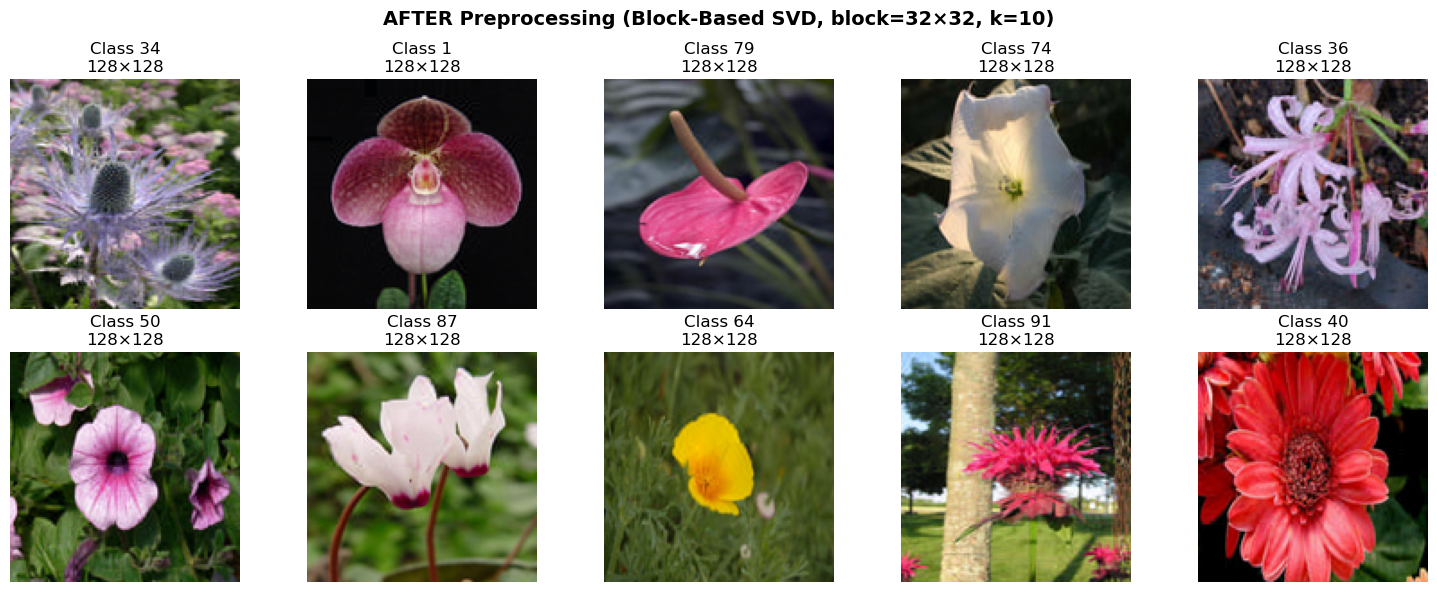

Block-Based SVD properties:
  - Standardized size: 128×128
  - Block size: 32×32
  - SVD compressed per block: A = U_k × Σ_k × V_T_k
  - k per block: 10
  - Features per image: 31,200
  - Original pixels: 49,152
  - Compression ratio: 1.58×


In [8]:
# ============================================================================
# AFTER Preprocessing: BLOCK-BASED SVD
# ============================================================================

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

np.random.seed(10)
random_indices_after = np.random.choice(len(X_train), 10, replace=False)

# Display
for idx, ax in enumerate(axes):
    img_idx = random_indices_after[idx]
    
    # Reconstruct from BLOCK-BASED SVD
    img = reconstruct_from_blocks(X_train[img_idx], k, IMAGE_SIZE, BLOCK_SIZE)
    
    # Normalize to 0-1 for display
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(f"Class {y_train[img_idx]}\n{IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}")
    ax.axis('off')

plt.suptitle(f"AFTER Preprocessing (Block-Based SVD, block={BLOCK_SIZE}×{BLOCK_SIZE}, k={k})", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Block-Based SVD properties:")
print(f"  - Standardized size: {IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}")
print(f"  - Block size: {BLOCK_SIZE}×{BLOCK_SIZE}")
print(f"  - SVD compressed per block: A = U_k × Σ_k × V_T_k")
print(f"  - k per block: {k}")
print(f"  - Features per image: {X_train.shape[1]:,}")
print(f"  - Original pixels: {IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3:,}")
print(f"  - Compression ratio: {(IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3) / X_train.shape[1]:.2f}×")

---

# Model 2: Artificial Neural Network

**PIPELINE OVERVIEW:**
1. Standardize features (mean=0, std=1)
2. Apply PCA for dimensionality reduction
3. Create PyTorch DataLoaders
4. Define ANN architecture
5. Train with early stopping
6. Hyperparameter search (optional)
7. Multi-seed evaluation for robustness

In [11]:
print("=" * 70)
print("ANN PREPROCESSING: STANDARDIZATION + PCA")
print("=" * 70)

# STEP 1: STANDARDIZATION
# Why: Neural networks learn best when all features have similar scales
# Method: Transform each feature to have mean=0 and standard deviation=1

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training only
X_valid_scaled = scaler.transform(X_valid)      # Apply to validation
X_test_scaled  = scaler.transform(X_test)       # Apply to test

print(f"✓ Scaled shapes: Train={X_train_scaled.shape}, Valid={X_valid_scaled.shape}")


ANN PREPROCESSING: STANDARDIZATION + PCA
✓ Scaled shapes: Train=(6552, 31200), Valid=(818, 31200)


In [12]:
pca_90 = PCA(n_components=0.98, random_state=42)
X_train_pca_90 = pca_90.fit_transform(X_train_scaled)

print(f"Components needed for 90% variance: {pca_90.n_components_}")

Components needed for 90% variance: 5854


In [14]:
# STEP 2: PCA DIMENSIONALITY REDUCTION
n_components = 5854

pca = PCA(n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)
X_test_pca  = pca.transform(X_test_scaled)

variance_retained = pca.explained_variance_ratio_.sum() * 100

print(f"✓ PCA complete:")
print(f"  Train: {X_train_pca.shape}")
print(f"  Valid: {X_valid_pca.shape}")
print(f"  Test:  {X_test_pca.shape}")
print(f"  Variance retained: {variance_retained:.2f}%")

✓ PCA complete:
  Train: (6552, 5854)
  Valid: (818, 5854)
  Test:  (819, 5854)
  Variance retained: 98.00%


VISUALIZING IMAGES AFTER PCA
Reconstructing 10 images from PCA features...



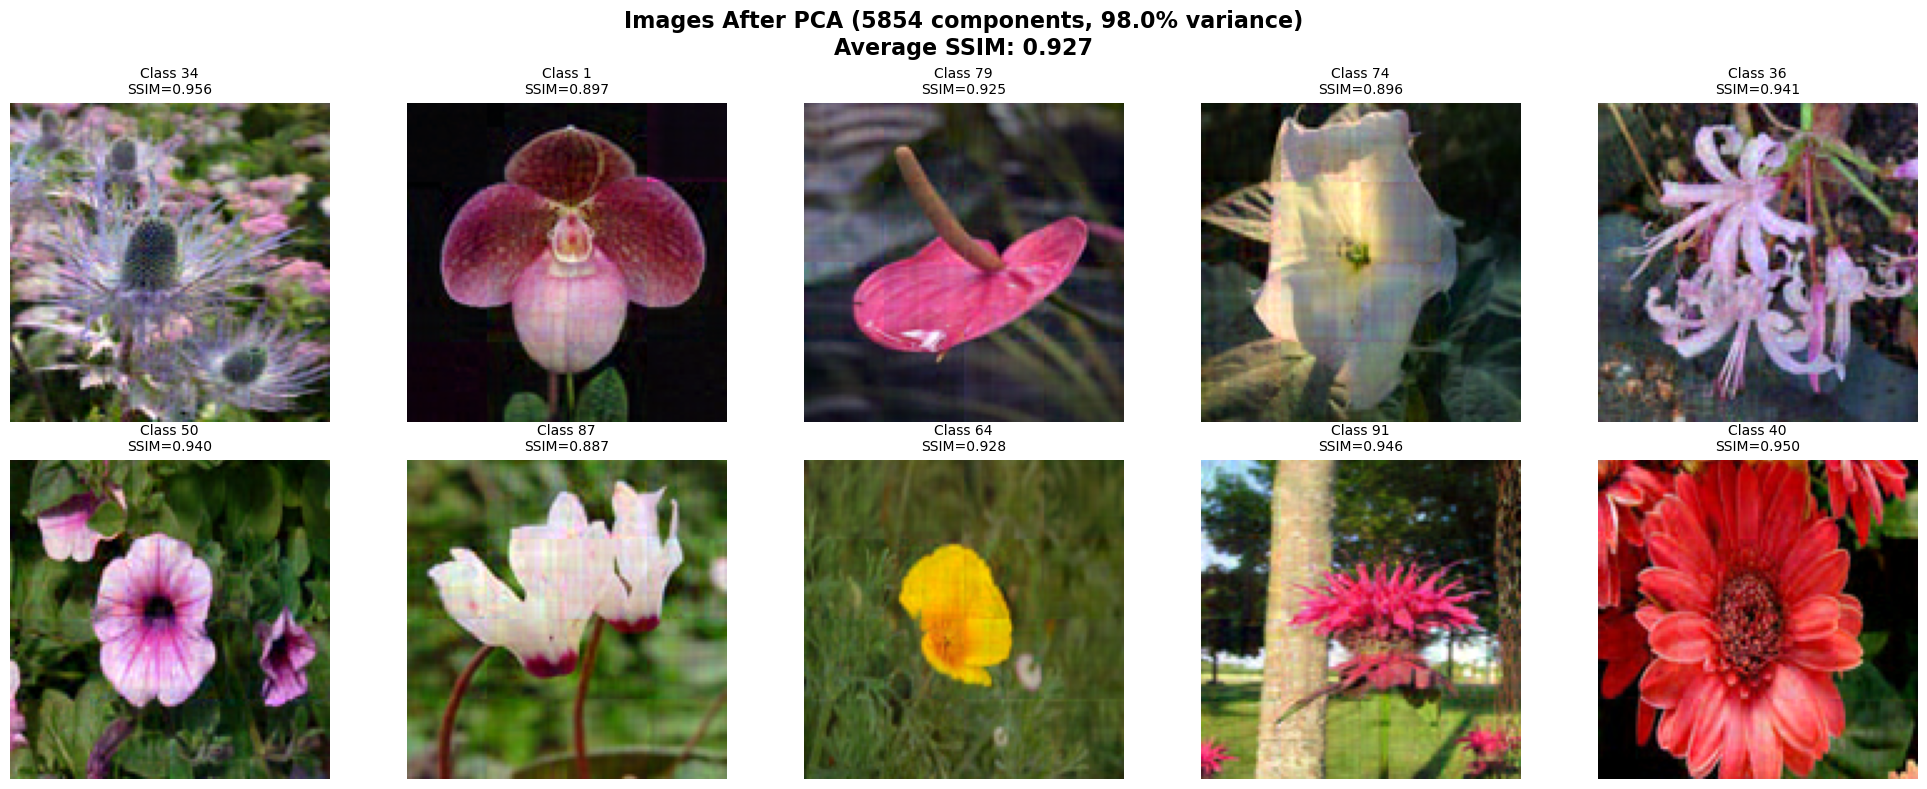

In [15]:
# STEP 3: SANITY CHECK - VISUALIZE PCA IMPACT
print("="*70)
print("VISUALIZING IMAGES AFTER PCA")
print("="*70)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

np.random.seed(10)
viz_indices = np.random.choice(len(X_train_pca), 10, replace=False)

print(f"Reconstructing {len(viz_indices)} images from PCA features...\n")

ssim_scores = []

for idx in range(10):
    sample_idx = viz_indices[idx]
    
    # Reconstruct: PCA → Scaled Features → Original Features → Image
    sample_pca = X_train_pca[sample_idx:sample_idx+1]  # Keep 2D shape
    sample_scaled = pca.inverse_transform(sample_pca)  # PCA → scaled features
    sample_features = scaler.inverse_transform(sample_scaled)[0]  # Scaled → original features
    
    # Reconstruct image from features
    img_reconstructed = reconstruct_from_blocks(sample_features, k, IMAGE_SIZE, BLOCK_SIZE)
    
    # Normalize for display
    img_norm = (img_reconstructed - img_reconstructed.min()) / (img_reconstructed.max() - img_reconstructed.min())
    
    # Calculate SSIM (compare with original Block SVD)
    img_original = reconstruct_from_blocks(X_train[sample_idx], k, IMAGE_SIZE, BLOCK_SIZE)
    ssim_score = ssim(img_original, img_reconstructed, channel_axis=2, data_range=255.0)
    ssim_scores.append(ssim_score)
    
    # Display
    axes[idx].imshow(img_norm)
    axes[idx].set_title(f"Class {y_train[sample_idx]}\nSSIM={ssim_score:.3f}", fontsize=10)
    axes[idx].axis('off')

avg_ssim = np.mean(ssim_scores)

plt.suptitle(f"Images After PCA ({n_components} components, {variance_retained:.1f}% variance)\nAverage SSIM: {avg_ssim:.3f}", 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 1.3) Create PyTorch DataLoaders
# Why: DataLoaders efficiently batch data and shuffle during training

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train_block, dtype=torch.long)

X_valid_t = torch.tensor(X_valid_pca, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid_block, dtype=torch.long)

X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True  # Shuffle training data each epoch
)

valid_loader = DataLoader(
    TensorDataset(X_valid_t, y_valid_t),
    batch_size=batch_size,
    shuffle=False  # Don't shuffle validation
)

print(f"✓ DataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")

In [82]:
# STEP 2: DEFINE ANN ARCHITECTURE
class SimpleANN(nn.Module):
    """
    Simple Artificial Neural Network for flower classification.
    
    Architecture:
        Input (PCA features) → Hidden1 → ReLU → Dropout → 
        Hidden2 → ReLU → Dropout → Output (102 classes)
    
    Args:
        input_dim: Number of input features (PCA components)
        hidden1: Number of neurons in first hidden layer
        hidden2: Number of neurons in second hidden layer
        dropout: Dropout probability (0.0-1.0) for regularization
        num_classes: Number of output classes (102 flower species)
    """
    def __init__(self, input_dim, hidden1=256, hidden2=256, dropout=0.5, num_classes=102):
        super().__init__()
        self.net = nn.Sequential(
            # First hidden layer
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),                      # Non-linear activation
            nn.Dropout(dropout),            # Regularization
            
            # Second hidden layer
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Output layer (no activation - handled by CrossEntropyLoss)
            nn.Linear(hidden2, num_classes),
        )
    
    def forward(self, x):
        return self.net(x)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model with default hyperparameters
model = SimpleANN(
    input_dim=X_train_pca.shape[1],  # 256 PCA components
    hidden1=256,
    hidden2=256,
    dropout=0.5,
    num_classes=102
).to(device)


### Initial Training 

In [83]:
# STEP 3: INITIAL TRAINING (BASELINE)

print("TRAINING BASELINE MODEL")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,              # Learning rate
    weight_decay=1e-3     # L2 regularization
)

# Training configuration
NUM_EPOCHS = 30
PATIENCE = 5  # Early stopping patience

# Helper function
def accuracy_from_logits(logits, y):
    """Calculate accuracy from model outputs."""
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

# Training loop
best_val_acc = 0.0
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\nTraining for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # -------------------------------------------------------------------------
    # Training phase
    # -------------------------------------------------------------------------
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        train_acc += accuracy_from_logits(logits, yb)
    
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    
    # -------------------------------------------------------------------------
    # Validation phase
    # -------------------------------------------------------------------------
    model.eval()
    val_acc = 0.0
    
    with torch.no_grad():
        for Xb, yb in valid_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            val_acc += accuracy_from_logits(logits, yb)
    
    val_acc /= len(valid_loader)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}%")
    
    # -------------------------------------------------------------------------
    # Early stopping check
    # -------------------------------------------------------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        torch.save(model.state_dict(), "best_ann_baseline.pth")
        print(f"  → New best! Saved model.")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping triggered. Best Val Acc: {best_val_acc*100:.2f}%")
            break

print("\n" + "=" * 70)
print(f"BASELINE TRAINING COMPLETE")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print("=" * 70)

TRAINING BASELINE MODEL

Training for up to 30 epochs (early stopping patience=5)

Epoch 01/30 | Loss: 4.6624 | Train Acc: 2.59% | Val Acc: 6.01%
  → New best! Saved model.
Epoch 02/30 | Loss: 4.3727 | Train Acc: 5.76% | Val Acc: 8.29%
  → New best! Saved model.
Epoch 03/30 | Loss: 4.0741 | Train Acc: 10.21% | Val Acc: 10.46%
  → New best! Saved model.
Epoch 04/30 | Loss: 3.6949 | Train Acc: 14.86% | Val Acc: 15.38%
  → New best! Saved model.
Epoch 05/30 | Loss: 3.2682 | Train Acc: 21.43% | Val Acc: 18.39%
  → New best! Saved model.
Epoch 06/30 | Loss: 2.8599 | Train Acc: 28.51% | Val Acc: 21.67%
  → New best! Saved model.
Epoch 07/30 | Loss: 2.5436 | Train Acc: 34.47% | Val Acc: 22.30%
  → New best! Saved model.
Epoch 08/30 | Loss: 2.2871 | Train Acc: 40.01% | Val Acc: 24.47%
  → New best! Saved model.
Epoch 09/30 | Loss: 2.0665 | Train Acc: 44.54% | Val Acc: 24.17%
Epoch 10/30 | Loss: 1.8715 | Train Acc: 49.33% | Val Acc: 24.57%
  → New best! Saved model.
Epoch 11/30 | Loss: 1.6896 |

In [85]:
# STEP 4: HYPERPARAMETER SEARCH

print("HYPERPARAMETER SEARCH")

# Set constants
NUM_CLASSES = 102
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------

def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def evaluate(model, loader):
    """Evaluate model on a dataloader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / max(total, 1)

def train_and_validate(X_train, y_train, X_valid, y_valid,
                       config, num_classes=102, epochs=30, 
                       batch_size=64, patience=5, seed=42, verbose=False):
    """
    Train model with given configuration.
    
    Returns:
        best_val_acc: Best validation accuracy achieved
        best_state: Model state dict at best validation
    """
    set_seed(seed)
    
    # Create dataloaders
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xva = torch.tensor(X_valid, dtype=torch.float32)
    yva = torch.tensor(y_valid, dtype=torch.long)
    
    train_loader = DataLoader(TensorDataset(Xtr, ytr), 
                              batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(Xva, yva), 
                              batch_size=batch_size, shuffle=False)
    
    # Create model
    model = SimpleANN(
        input_dim=X_train.shape[1],
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"],
        num_classes=num_classes
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    
    best_val = -1.0
    best_state = None
    wait = 0
    
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        
        # Validate
        val_acc = evaluate(model, valid_loader)
        
        if verbose:
            print(f"  Epoch {epoch:02d}/{epochs} | Val {val_acc*100:.2f}%")
        
        # Early stopping
        if val_acc > best_val + 1e-6:
            best_val = val_acc
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    
    return best_val, best_state

def apply_pca(X_train_scaled, X_valid_scaled, pca_dim, seed=42):
    """Apply PCA transformation."""
    pca = PCA(n_components=pca_dim, random_state=seed)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_valid_pca = pca.transform(X_valid_scaled)
    var_retained = float(pca.explained_variance_ratio_.sum())
    return X_train_pca, X_valid_pca, var_retained, pca

# -----------------------------------------------------------------------------
# Define Search Space
# -----------------------------------------------------------------------------

search_space = {
    "pca_dim":      [256, 512, 1024],
    "hidden1":      [256, 512, 768],
    "hidden2":      [128, 256],
    "dropout":      [0.3, 0.4, 0.5],
    "lr":           [1e-3, 5e-4, 3e-4],
    "weight_decay": [1e-4, 1e-3, 5e-3],
}

# Generate all combinations
MAX_TRIALS = 10  # Limit for computational efficiency
all_configs = list(product(
    search_space["pca_dim"],
    search_space["hidden1"],
    search_space["hidden2"],
    search_space["dropout"],
    search_space["lr"],
    search_space["weight_decay"],
))

# Shuffle and limit (random search)
rng = np.random.default_rng(42)
rng.shuffle(all_configs)
all_configs = all_configs[:MAX_TRIALS]

print(f"\nSearching {len(all_configs)} hyperparameter configurations...")
print(f"This will take approximately {len(all_configs) * 2} minutes.\n")

# -----------------------------------------------------------------------------
# Run Search
# -----------------------------------------------------------------------------

best_overall = {
    "val_acc": -1.0,
    "config": None,
    "state_dict": None,
    "pca": None,
    "variance_retained": None
}

for idx, (pca_dim, h1, h2, dr, lr, wd) in enumerate(all_configs, start=1):
    # Apply PCA with current dimension
    Xtr_pca, Xva_pca, var_ret, pca_obj = apply_pca(
        X_train_scaled, X_valid_scaled, pca_dim, seed=42
    )
    
    config = {
        "pca_dim": pca_dim,
        "hidden1": h1,
        "hidden2": h2,
        "dropout": dr,
        "lr": lr,
        "weight_decay": wd
    }
    
    # Train and validate
    val_acc, state = train_and_validate(
        Xtr_pca, y_train,
        Xva_pca, y_valid,
        config=config,
        num_classes=NUM_CLASSES,
        epochs=30,
        batch_size=64,
        patience=5,
        seed=42,
        verbose=False
    )
    
    print(f"[{idx:02d}/{MAX_TRIALS}] PCA={pca_dim} (var={var_ret*100:.1f}%) | "
          f"h1={h1} h2={h2} dr={dr:.1f} lr={lr:.4f} wd={wd:.4f} "
          f"→ Val={val_acc*100:.2f}%")
    
    # Update best
    if val_acc > best_overall["val_acc"]:
        best_overall.update({
            "val_acc": val_acc,
            "config": config,
            "state_dict": state,
            "pca": pca_obj,
            "variance_retained": var_ret
        })
        print(f"  🌟 NEW BEST!")

# -----------------------------------------------------------------------------
# Results
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("HYPERPARAMETER SEARCH COMPLETE")
print("=" * 70)
print(f"\nBest Validation Accuracy: {best_overall['val_acc']*100:.2f}%")
print(f"Variance Retained (PCA): {best_overall['variance_retained']*100:.2f}%")
print(f"\nBest Configuration:")
for key, value in best_overall["config"].items():
    print(f"  {key:15s}: {value}")

# -----------------------------------------------------------------------------
# Save Best Model
# -----------------------------------------------------------------------------

import joblib

torch.save(best_overall["state_dict"], "best_ann_hypersearch.pth")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(best_overall["pca"], "pca_best.joblib")

print(f"\n✓ Saved: best_ann_hypersearch.pth, scaler.joblib, pca_best.joblib")
print("=" * 70)

HYPERPARAMETER SEARCH

Searching 10 hyperparameter configurations...
This will take approximately 20 minutes.

[01/10] PCA=512 (var=18.8%) | h1=256 h2=256 dr=0.4 lr=0.0003 wd=0.0001 → Val=31.17%
  🌟 NEW BEST!
[02/10] PCA=512 (var=18.8%) | h1=256 h2=256 dr=0.5 lr=0.0003 wd=0.0001 → Val=29.83%
[03/10] PCA=512 (var=18.8%) | h1=256 h2=128 dr=0.4 lr=0.0005 wd=0.0050 → Val=28.97%
[04/10] PCA=512 (var=18.8%) | h1=768 h2=256 dr=0.3 lr=0.0003 wd=0.0050 → Val=30.56%
[05/10] PCA=256 (var=11.8%) | h1=768 h2=256 dr=0.3 lr=0.0010 wd=0.0001 → Val=30.81%
[06/10] PCA=256 (var=11.8%) | h1=256 h2=256 dr=0.4 lr=0.0005 wd=0.0010 → Val=33.13%
  🌟 NEW BEST!
[07/10] PCA=512 (var=18.8%) | h1=512 h2=128 dr=0.3 lr=0.0010 wd=0.0010 → Val=26.77%
[08/10] PCA=512 (var=18.8%) | h1=768 h2=256 dr=0.4 lr=0.0005 wd=0.0010 → Val=30.07%
[09/10] PCA=1024 (var=30.1%) | h1=256 h2=256 dr=0.3 lr=0.0003 wd=0.0010 → Val=25.18%
[10/10] PCA=512 (var=18.8%) | h1=512 h2=256 dr=0.5 lr=0.0010 wd=0.0010 → Val=28.85%

HYPERPARAMETER SEAR

In [36]:
# ==============================================================================
# STEP 5: MULTI-SEED ROBUSTNESS TEST
# ==============================================================================

print("=" * 70)
print("TESTING ROBUSTNESS ACROSS MULTIPLE SEEDS")
print("=" * 70)

# Load best hyperparameters from search
best_config = best_overall["config"]

# Load best PCA
pca_best = joblib.load("pca_best.joblib")
X_train_pca_best = pca_best.transform(X_train_scaled)
X_valid_pca_best = pca_best.transform(X_valid_scaled)

print(f"\nUsing best hyperparameters:")
for key, value in best_config.items():
    print(f"  {key:15s}: {value}")

# Test multiple seeds
test_seeds = [1, 13, 24, 42, 50, 69, 73, 88, 96, 123, 999]

print(f"\nTraining with {len(test_seeds)} different random seeds...")
print("This tests how sensitive the model is to initialization.\n")

results = []

for seed in test_seeds:
    val_acc, model_state = train_and_validate(
        X_train_pca_best, y_train,
        X_valid_pca_best, y_valid,
        config=best_config,
        num_classes=NUM_CLASSES,
        epochs=30,
        batch_size=64,
        patience=5,
        seed=seed,
        verbose=False
    )
    
    results.append({
        'seed': seed,
        'val_acc': val_acc
    })
    
    print(f"Seed {seed:3d}: Val Acc = {val_acc*100:.2f}%")

# Summary statistics
val_accs = [r['val_acc'] for r in results]
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs)
best_seed = results[np.argmax(val_accs)]['seed']
best_seed_acc = max(val_accs)

print("\n" + "=" * 70)
print("MULTI-SEED RESULTS")
print("=" * 70)
print(f"Mean Validation Accuracy: {mean_acc*100:.2f}%")
print(f"Std Deviation:            {std_acc*100:.2f}%")
print(f"Best Seed:                {best_seed} ({best_seed_acc*100:.2f}%)")
print(f"Worst Seed:               {results[np.argmin(val_accs)]['seed']} ({min(val_accs)*100:.2f}%)")
print("=" * 70)

# Visualize distribution
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('val_acc', ascending=False)
print("\nFull Results (sorted by accuracy):")
print(df_results.to_string(index=False))

TESTING ROBUSTNESS ACROSS MULTIPLE SEEDS

Using best hyperparameters:
  pca_dim        : 256
  hidden1        : 256
  hidden2        : 256
  dropout        : 0.5
  lr             : 0.001
  weight_decay   : 0.0001

Training with 11 different random seeds...
This tests how sensitive the model is to initialization.

Seed   1: Val Acc = 15.77%
Seed  13: Val Acc = 16.87%
Seed  24: Val Acc = 16.87%
Seed  42: Val Acc = 17.73%
Seed  50: Val Acc = 17.24%
Seed  69: Val Acc = 16.14%
Seed  73: Val Acc = 18.09%
Seed  88: Val Acc = 18.46%
Seed  96: Val Acc = 16.38%
Seed 123: Val Acc = 16.99%
Seed 999: Val Acc = 16.87%

MULTI-SEED RESULTS
Mean Validation Accuracy: 17.04%
Std Deviation:            0.77%
Best Seed:                88 (18.46%)
Worst Seed:               1 (15.77%)

Full Results (sorted by accuracy):
 seed  val_acc
   88 0.184597
   73 0.180929
   42 0.177262
   50 0.172372
  123 0.169927
   13 0.168704
   24 0.168704
  999 0.168704
   96 0.163814
   69 0.161369
    1 0.157702


### Final Model

In [ ]:
# ==============================================================================
# STEP 6: FINAL MODEL SELECTION
# ==============================================================================

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

# Decision: Use best seed with best hyperparameters
FINAL_SEED = best_seed  # From multi-seed test

print(f"\nTraining final model with:")
print(f"  - Best hyperparameters from grid search")
print(f"  - Best seed from robustness test: {FINAL_SEED}")
print(f"\nThis combines both optimization strategies.\n")

# Train final model
final_val_acc, final_state = train_and_validate(
    X_train_pca_best, y_train,
    X_valid_pca_best, y_valid,
    config=best_config,
    num_classes=NUM_CLASSES,
    epochs=30,
    batch_size=64,
    patience=5,
    seed=FINAL_SEED,
    verbose=True  # Show epoch-by-epoch progress
)

# Save final model
torch.save(final_state, "best_ann_final.pth")

print("\n" + "=" * 70)
print("FINAL MODEL TRAINING COMPLETE")
print("=" * 70)
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Improvement over baseline: {(final_val_acc - best_val_acc)*100:.2f}%")
print(f"\n✓ Saved: best_ann_final.pth")
print("=" * 70)

---

# Model 3: Convolutional Neural Network

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch import optim
from tqdm import tqdm

In [88]:
def prepare_for_cnn(X_svd, y):
    """ OLD:
    Reshape flattened SVD images to CNN format (N, C, H, W).
    # Reshape from (N, k*k*3) to (N, k, k, 3)
    X_reshaped = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    # Convert to (N, 3, k, k) - PyTorch expects channels first
    X_reshaped = np.transpose(X_reshaped, (0, 3, 1, 2))
    # Normalize to [0, 1]
    X_reshaped = (X_reshaped - X_reshaped.min()) / (X_reshaped.max() - X_reshaped.min())
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    return X_tensor, y_tensor """

    # NEW: Reconstruct images from SVD components, then prepare for CNN
    print(f"🔄 Reconstructing {len(X_svd)} images from SVD features...")
    
    # Step 1: Reconstruct all images from SVD components
    X_reconstructed = []
    for i in range(len(X_svd)):
        img = reconstruct_from_features(X_svd[i], k, IMAGE_SIZE)
        X_reconstructed.append(img)
        
        # Progress indicator
        if (i + 1) % 1000 == 0:
            print(f"  Reconstructed {i+1}/{len(X_svd)} images...")
    
    X_reconstructed = np.array(X_reconstructed)  # Shape: (N, 128, 128, 3)
    print(f"✓ Reconstruction complete: {X_reconstructed.shape}")
    
    # Step 2: Convert to (N, 3, H, W) - PyTorch format (channels first)
    X_reshaped = np.transpose(X_reconstructed, (0, 3, 1, 2))
    
    # Step 3: Normalize to [0, 1]
    X_reshaped = X_reshaped / 255.0  # Images are 0-255, normalize to 0-1
    
    # Step 4: Convert to tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    
    return X_tensor, y_tensor


# Prepare data (this will take a few minutes)
print("="*70)
print("PREPARING DATA FOR CNN")
print("="*70)

# For test set, create dummy labels (they won't be used for evaluation anyway)
y_test = np.zeros(len(X_test_block), dtype=int)  # All zeros (placeholder)

X_train_tensor, y_train_tensor = prepare_for_cnn(X_train_block, y_train_block)
X_valid_tensor, y_valid_tensor = prepare_for_cnn(X_valid_block, y_valid_block)
X_test_tensor, y_test_tensor = prepare_for_cnn(X_test_block, y_test)

print(f"\n✓ All data prepared!")
print(f"  X_train_tensor: {X_train_tensor.shape}")  # (6552, 3, 128, 128)
print(f"  X_valid_tensor: {X_valid_tensor.shape}")  # (818, 3, 128, 128)
print(f"  X_test_tensor:  {X_test_tensor.shape}")   # (819, 3, 128, 128)

# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")
print("="*70)

PREPARING DATA FOR CNN
🔄 Reconstructing 6552 images from SVD features...
  Reconstructed 1000/6552 images...
  Reconstructed 2000/6552 images...
  Reconstructed 3000/6552 images...
  Reconstructed 4000/6552 images...
  Reconstructed 5000/6552 images...
  Reconstructed 6000/6552 images...
✓ Reconstruction complete: (6552, 128, 128, 3)
🔄 Reconstructing 818 images from SVD features...
✓ Reconstruction complete: (818, 128, 128, 3)
🔄 Reconstructing 819 images from SVD features...
✓ Reconstruction complete: (819, 128, 128, 3)

✓ All data prepared!
  X_train_tensor: torch.Size([6552, 3, 128, 128])
  X_valid_tensor: torch.Size([818, 3, 128, 128])
  X_test_tensor:  torch.Size([819, 3, 128, 128])

✓ DataLoaders created:
  Train batches: 205
  Valid batches: 26
  Test batches: 26


In [89]:
class CNN(nn.Module):
    def __init__(self, input_size, in_channels=3, num_classes=102):
        super(CNN, self).__init__()
        
        # Conv blocks with Batch Normalization
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout_conv = nn.Dropout2d(0.25)  # Dropout for conv layers
        
        # Calculate FC size
        fc_size = input_size // 8
        
        self.fc1 = nn.Linear(128 * fc_size * fc_size, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)
        
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(F.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN(input_size=IMAGE_SIZE[0], in_channels=3, num_classes=102).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

num_epochs = 30  # More epochs since we have early stopping

In [91]:

best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        data = data.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, targets in valid_loader:
            data = data.to(device)
            targets = targets.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
    
    val_acc = 100. * val_correct / val_total
    
    # Step scheduler based on validation accuracy
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"  ↓ Learning rate reduced: {old_lr} → {new_lr}")
    
    print(f"  Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (Val Acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))

Epoch 1/30: 100%|██████████| 205/205 [01:18<00:00,  2.61it/s]


  Loss: 4.6885 | Train Acc: 2.73% | Val Acc: 4.03%
  ✓ New best model saved! (Val Acc: 4.03%)


Epoch 2/30:  78%|███████▊  | 160/205 [01:00<00:17,  2.63it/s]


KeyboardInterrupt: 

In [ ]:
from torchmetrics import Accuracy

acc_metric = Accuracy(task="multiclass", num_classes=102).to(device)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        acc_metric.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = acc_metric.compute()
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print("\n⚠️ Note: Test labels are placeholders (all zeros).")